# **Capstone project: Providing data-driven suggestions for HR**

## Description and deliverables

This capstone project is an opportunity for you to analyze a dataset and build predictive models that can provide insights to the Human Resources (HR) department of a large consulting firm.

Upon completion, you will have two artifacts that you will be able to present to future employers. One is a brief one-page summary of this project that you will present to external stakeholders as the data professional in Salifort Motors. The other is a complete code notebook provided here. Based on your prior coursework, select one method to complete this project: use either a regression model or a machine learning model to predict whether an employee will leave the company. The exemplar following this actiivty shows both approaches, but you only need to do one.

In your deliverables, you will include the model evaluation (and interpretation if applicable), a data visualization(s) of your choice that is directly related to the question you ask, ethical considerations, and the resources you used to troubleshoot and find answers or solutions.


# **PACE stages**


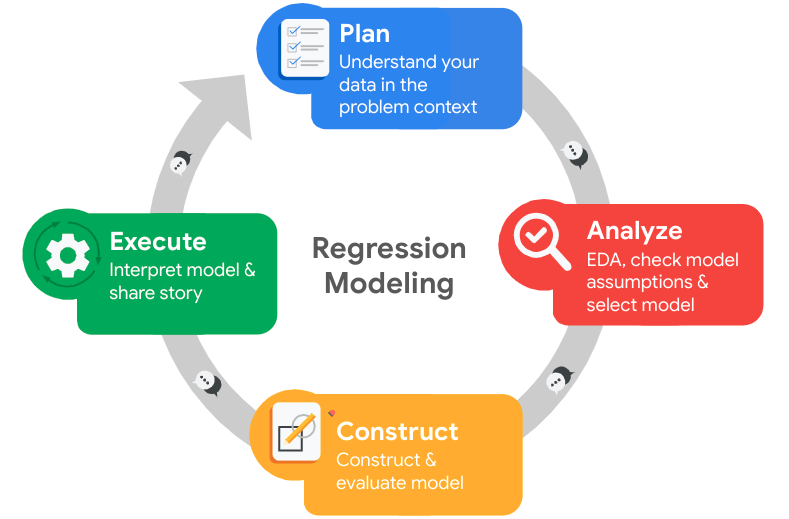

## **Pace: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following:

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize yourself with the HR dataset

The dataset that you'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below. 

**Note:** you don't need to download any data to complete this lab. For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

💭
### Reflect on these questions as you complete the plan stage.

*  Who are your stakeholders for this project?
- What are you trying to solve or accomplish?
- What are your initial observations when you explore the data?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




1. The stakeholders are the hiring managers and hr team. They would like to improve employee retention. 
2. We are trying to predict whether an employee is likely to leave the company or not, by finding the problem areas, we can start to solve the problem.
3. 
4. I have to be aware that I am using personal data for this exploration. I need to be conscious that none of the features I'm using will lead to a biased model.

## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [3]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import pickle
import shap


### Load dataset

`Pandas` is used to read a dataset called **`HR_capstone_dataset.csv`.**  As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [ ]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

# Load dataset into a dataframe

df0 = pd.read_csv("HR_capstone_dataset.csv")

# Display first few rows of the dataframe
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [5]:
# Gather basic information about the data
df0.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

### Gather descriptive statistics about the data

In [6]:
# Gather descriptive statistics about the data
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [7]:
# Display all column names
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='str')

In [8]:
# Rename columns as needed
df0.rename(
    columns={'average_montly_hours': 'average_monthly_hours', 
             'Work_accident' : 'work_accident', 
             'Department' : 'department'}, 
    inplace=True)

# Display all column names after the update
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'time_spend_company', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='str')

### Check missing values

Check for any missing values in the data.

In [9]:
# Check for missing values
df0.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
time_spend_company       0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

### Check duplicates

Check for any duplicate entries in the data.

In [10]:
# Check for duplicates
df0.duplicated().sum()

np.int64(3008)

In [11]:
# Inspect some rows containing duplicates as needed
df0[df0.duplicated()]

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [12]:
# Drop duplicates and save resulting dataframe in a new variable as needed
df0_no_duplicates = df0.drop_duplicates()


# Display first few rows of new dataframe as needed
df0_no_duplicates.head()


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Check outliers

Check for outliers in the data.

Text(0, 0.5, 'Years')

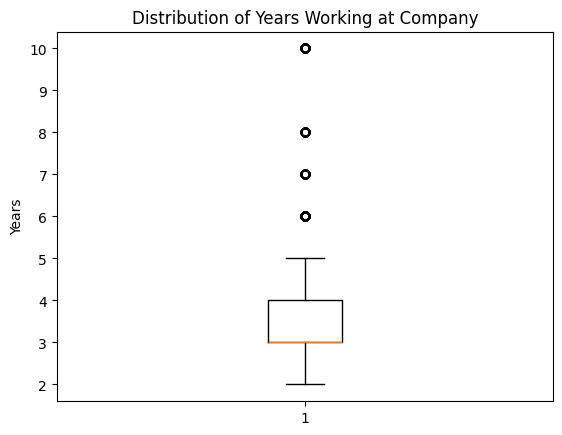

In [13]:
# Create a boxplot to visualize distribution of `time_spend_company` and detect any outliers

plt.boxplot(df0_no_duplicates['time_spend_company'])
plt.title('Distribution of Years Working at Company')
plt.ylabel('Years')


In [14]:
# Determine the number of rows containing outliers
Q3 = df0_no_duplicates['work_accident'].quantile(.75)
Q1 = df0_no_duplicates['work_accident'].quantile(.25)
IQR = Q3 - Q1

lower_bound = Q1 - (1.5*IQR)
upper_bound = Q3 + (1.5*IQR)

outlier_rows = df0_no_duplicates[(df0_no_duplicates['work_accident'] < lower_bound) | (df0_no_duplicates['work_accident'] > upper_bound)]
print("Work accident outliers:", outlier_rows['work_accident'].count())


Q3 = df0_no_duplicates['promotion_last_5years'].quantile(.75)
Q1 = df0_no_duplicates['promotion_last_5years'].quantile(.25)
IQR = Q3 - Q1

lower_bound = Q1 - (1.5*IQR)
upper_bound = Q3 + (1.5*IQR)

outlier_rows2 = df0_no_duplicates[(df0_no_duplicates['promotion_last_5years'] < lower_bound) | (df0_no_duplicates['promotion_last_5years'] > upper_bound)]
print("Promotion outliers:", outlier_rows2['promotion_last_5years'].count())

Q3 = df0_no_duplicates['time_spend_company'].quantile(.75)
Q1 = df0_no_duplicates['time_spend_company'].quantile(.25)
IQR = Q3 - Q1

lower_bound = Q1 - (1.5*IQR)
upper_bound = Q3 + (1.5*IQR)

outlier_rows2 = df0_no_duplicates[(df0_no_duplicates['time_spend_company'] < lower_bound) | (df0_no_duplicates['time_spend_company'] > upper_bound)]
print("Years at company outliers", outlier_rows2['time_spend_company'].count())

Work accident outliers: 1850
Promotion outliers: 203
Years at company outliers 824


Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



💭
### Reflect on these questions as you complete the analyze stage.

- What did you observe about the relationships between variables?
- What do you observe about the distributions in the data?
- What transformations did you make with your data? Why did you chose to make those decisions?
- What are some purposes of EDA before constructing a predictive model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




[Double-click to enter your responses here.]

## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [15]:
# Get numbers of people who left vs. stayed
print(df0_no_duplicates.left.value_counts())
# Get percentages of people who left vs. stayed
print("Employees retained:", round(df0_no_duplicates.left.mean()*100), '%')


left
0    10000
1     1991
Name: count, dtype: int64
Employees retained: 17 %


### Data visualizations

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

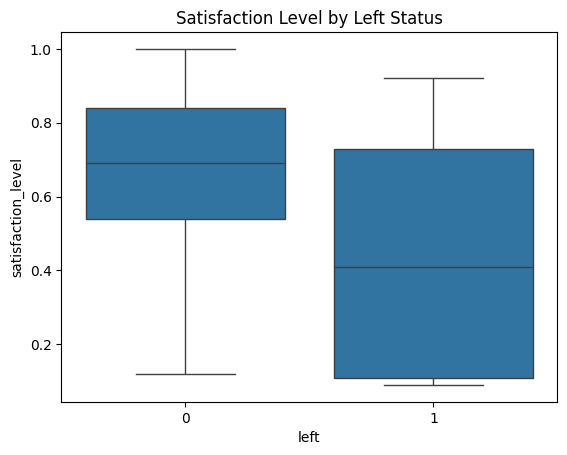

In [16]:
# Create a plot as needed
sns.boxplot(x='left', y='satisfaction_level', data=df0_no_duplicates)
plt.title('Satisfaction Level by Left Status')
plt.show()


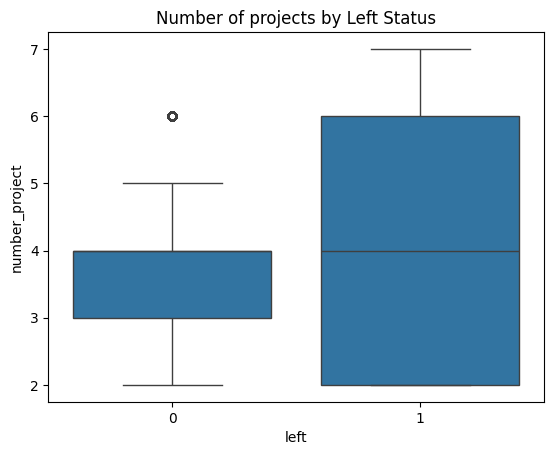

In [17]:
# Create a plot as needed
sns.boxplot(x='left', y='number_project', data=df0_no_duplicates)
plt.title('Number of projects by Left Status')
plt.show()

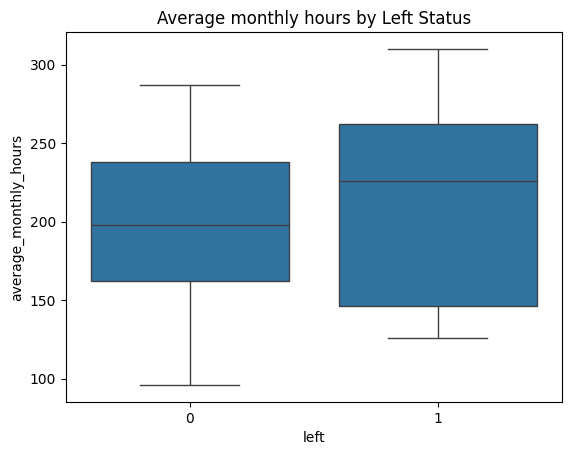

In [18]:
# Create a plot as needed
sns.boxplot(x='left', y='average_monthly_hours', data=df0_no_duplicates)
plt.title('Average monthly hours by Left Status')
plt.show()

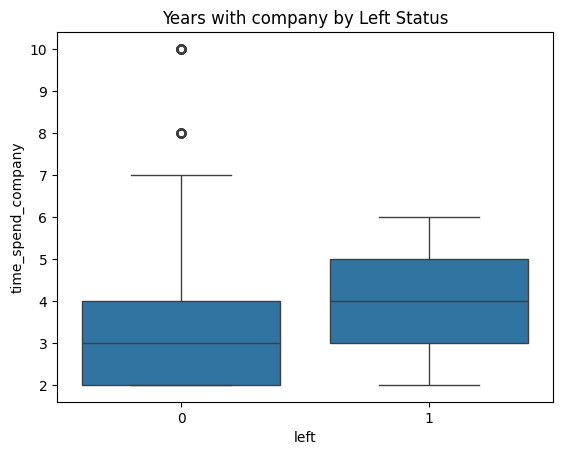

In [19]:
# Create a plot as needed
sns.boxplot(x='left', y='time_spend_company', data=df0_no_duplicates)
plt.title('Years with company by Left Status')
plt.show()

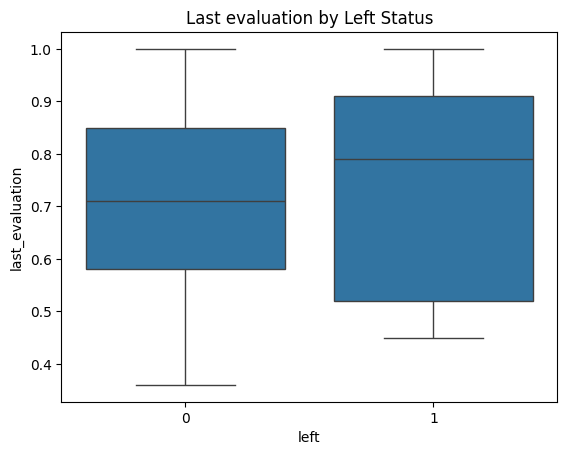

In [20]:
# Create a plot as needed
sns.boxplot(x='left', y='last_evaluation', data=df0_no_duplicates)
plt.title('Last evaluation by Left Status')
plt.show()

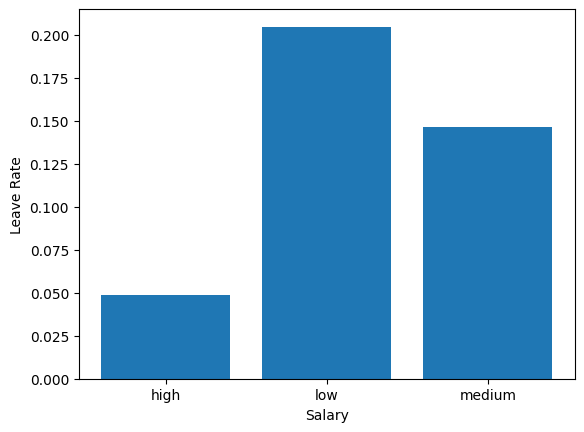

In [21]:
# Create a plot as needed
rates = df0_no_duplicates.groupby('salary')['left'].mean()

plt.bar(rates.index, rates.values)
plt.xlabel('Salary')
plt.ylabel('Leave Rate')
plt.show()

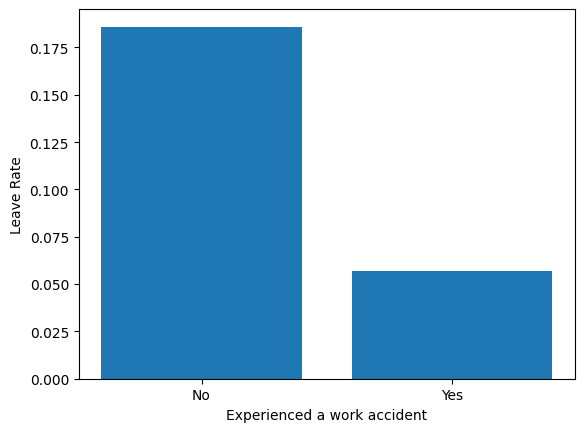

In [22]:
# Create a plot as needed
rates = df0_no_duplicates.groupby('work_accident')['left'].mean()

plt.bar(rates.index, rates.values)
plt.xlabel('Experienced a work accident')
plt.xticks(rates.index,labels=['No', 'Yes'])
plt.ylabel('Leave Rate')
plt.show()

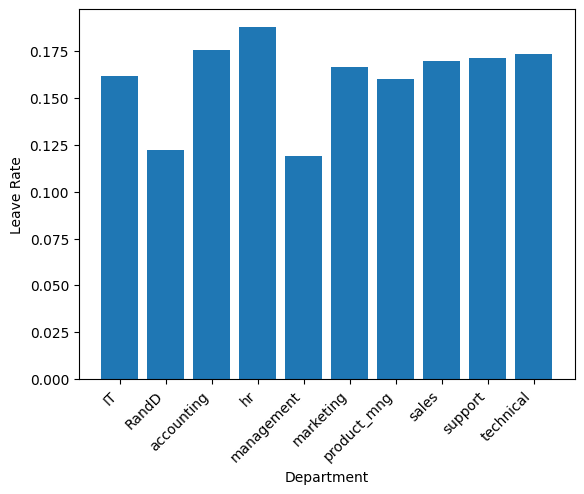

In [23]:
# Create a plot as needed
rates = df0_no_duplicates.groupby('department')['left'].mean()

plt.bar(rates.index, rates.values)
plt.xlabel('Department')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Leave Rate')
plt.show()

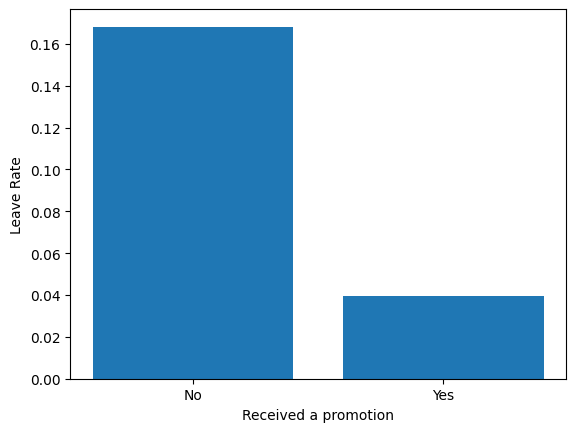

In [24]:
rates = df0_no_duplicates.groupby('promotion_last_5years')['left'].mean()

plt.bar(rates.index, rates.values)
plt.xticks(rates.index,labels=['No', 'Yes'])
plt.xlabel('Received a promotion')
plt.ylabel('Leave Rate')
plt.show()

In [25]:
df0_no_duplicates['hours_per_project'] = df0_no_duplicates['average_monthly_hours'] / df0_no_duplicates['number_project']
df0_no_duplicates.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary,hours_per_project
0,0.38,0.53,2,157,3,0,1,0,sales,low,78.500000
1,0.80,0.86,5,262,6,0,1,0,sales,medium,52.400000
2,0.11,0.88,7,272,4,0,1,0,sales,medium,38.857143
3,0.72,0.87,5,223,5,0,1,0,sales,low,44.600000
4,0.37,0.52,2,159,3,0,1,0,sales,low,79.500000


In [26]:
df0_no_duplicates['promotion_freq'] = df0_no_duplicates['promotion_last_5years'] / df0_no_duplicates['time_spend_company']
df0_no_duplicates.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary,hours_per_project,promotion_freq
0,0.38,0.53,2,157,3,0,1,0,sales,low,78.500000,0.0
1,0.80,0.86,5,262,6,0,1,0,sales,medium,52.400000,0.0
2,0.11,0.88,7,272,4,0,1,0,sales,medium,38.857143,0.0
3,0.72,0.87,5,223,5,0,1,0,sales,low,44.600000,0.0
4,0.37,0.52,2,159,3,0,1,0,sales,low,79.500000,0.0


In [27]:
df0_no_duplicates['eval_satisfaction_diff'] = df0_no_duplicates['last_evaluation'] - df0_no_duplicates['satisfaction_level']
df0_no_duplicates.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary,hours_per_project,promotion_freq,eval_satisfaction_diff
0,0.38,0.53,2,157,3,0,1,0,sales,low,78.500000,0.0,0.15
1,0.80,0.86,5,262,6,0,1,0,sales,medium,52.400000,0.0,0.06
2,0.11,0.88,7,272,4,0,1,0,sales,medium,38.857143,0.0,0.77
3,0.72,0.87,5,223,5,0,1,0,sales,low,44.600000,0.0,0.15
4,0.37,0.52,2,159,3,0,1,0,sales,low,79.500000,0.0,0.15


In [28]:
df0_no_duplicates['satisfaction_per_project'] = df0_no_duplicates['satisfaction_level'] / df0_no_duplicates['number_project']
df0_no_duplicates.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,salary,hours_per_project,promotion_freq,eval_satisfaction_diff,satisfaction_per_project
0,0.38,0.53,2,157,3,0,1,0,sales,low,78.500000,0.0,0.15,0.190000
1,0.80,0.86,5,262,6,0,1,0,sales,medium,52.400000,0.0,0.06,0.160000
2,0.11,0.88,7,272,4,0,1,0,sales,medium,38.857143,0.0,0.77,0.015714
3,0.72,0.87,5,223,5,0,1,0,sales,low,44.600000,0.0,0.15,0.144000
4,0.37,0.52,2,159,3,0,1,0,sales,low,79.500000,0.0,0.15,0.185000


### Insights

[What insights can you gather from the plots you created to visualize the data? Double-click to enter your responses here.]

# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


🔎
## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size





💭
### Reflect on these questions as you complete the constructing stage.

- Do you notice anything odd?
- Which independent variables did you choose for the model and why?
- Are each of the assumptions met?
- How well does your model fit the data?
- Can you improve it? Is there anything you would change about the model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



I have decided to use all the data provided. I have also added a few engineered features to further improve performance. These engineered features are:
- hours per project
- promotion frequency
- difference between evaluation and satisfaction
- satisfaction per project

* After testing the model and producing a 95% f1 score, I have decided that any further tuning may lead to overfitting the model.
The data does not have any protected features (gender, age, etc.) so I will commence simply with the awareness of measuring real, human, data. 

## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.

This is a binary prediction task.

### Identify the types of models most appropriate for this task.

Either a logistic regression or a tree based model will be the best predictor. I have decided to test both Random Forest Regression and XGBoost. 

### Modeling

Add as many cells as you need to conduct the modeling process.

In [29]:
dummies = pd.get_dummies(df0_no_duplicates['salary'], drop_first=True, dtype=int)
df0_no_duplicates = pd.concat([df0_no_duplicates.drop('salary', axis=1), dummies], axis=1)
df0_no_duplicates

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,hours_per_project,promotion_freq,eval_satisfaction_diff,satisfaction_per_project,low,medium
0,0.38,0.53,2,157,3,0,1,0,sales,78.500000,0.0,0.15,0.190000,1,0
1,0.80,0.86,5,262,6,0,1,0,sales,52.400000,0.0,0.06,0.160000,0,1
2,0.11,0.88,7,272,4,0,1,0,sales,38.857143,0.0,0.77,0.015714,0,1
3,0.72,0.87,5,223,5,0,1,0,sales,44.600000,0.0,0.15,0.144000,1,0
4,0.37,0.52,2,159,3,0,1,0,sales,79.500000,0.0,0.15,0.185000,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,0.90,0.55,3,259,10,1,0,1,management,86.333333,0.1,-0.35,0.300000,0,0
11996,0.74,0.95,5,266,10,0,0,1,management,53.200000,0.1,0.21,0.148000,0,0
11997,0.85,0.54,3,185,10,0,0,1,management,61.666667,0.1,-0.31,0.283333,0,0
11998,0.33,0.65,3,172,10,0,0,1,marketing,57.333333,0.1,0.32,0.110000,0,0


In [30]:
df0_no_duplicates['department'] = df0_no_duplicates['department'].astype('category')


In [31]:
df0_no_duplicates.info()

<class 'pandas.DataFrame'>
Index: 11991 entries, 0 to 11999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   satisfaction_level        11991 non-null  float64 
 1   last_evaluation           11991 non-null  float64 
 2   number_project            11991 non-null  int64   
 3   average_monthly_hours     11991 non-null  int64   
 4   time_spend_company        11991 non-null  int64   
 5   work_accident             11991 non-null  int64   
 6   left                      11991 non-null  int64   
 7   promotion_last_5years     11991 non-null  int64   
 8   department                11991 non-null  category
 9   hours_per_project         11991 non-null  float64 
 10  promotion_freq            11991 non-null  float64 
 11  eval_satisfaction_diff    11991 non-null  float64 
 12  satisfaction_per_project  11991 non-null  float64 
 13  low                       11991 non-null  int64   
 14  medium

In [32]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

encoder.fit(df0_no_duplicates['department'])
df0_no_duplicates['department_num'] = encoder.transform(df0_no_duplicates['department'])


In [33]:
df0_no_duplicates

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,work_accident,left,promotion_last_5years,department,hours_per_project,promotion_freq,eval_satisfaction_diff,satisfaction_per_project,low,medium,department_num
0,0.38,0.53,2,157,3,0,1,0,sales,78.500000,0.0,0.15,0.190000,1,0,7
1,0.80,0.86,5,262,6,0,1,0,sales,52.400000,0.0,0.06,0.160000,0,1,7
2,0.11,0.88,7,272,4,0,1,0,sales,38.857143,0.0,0.77,0.015714,0,1,7
3,0.72,0.87,5,223,5,0,1,0,sales,44.600000,0.0,0.15,0.144000,1,0,7
4,0.37,0.52,2,159,3,0,1,0,sales,79.500000,0.0,0.15,0.185000,1,0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,0.90,0.55,3,259,10,1,0,1,management,86.333333,0.1,-0.35,0.300000,0,0,4
11996,0.74,0.95,5,266,10,0,0,1,management,53.200000,0.1,0.21,0.148000,0,0,4
11997,0.85,0.54,3,185,10,0,0,1,management,61.666667,0.1,-0.31,0.283333,0,0,4
11998,0.33,0.65,3,172,10,0,0,1,marketing,57.333333,0.1,0.32,0.110000,0,0,5


In [34]:
X = df0_no_duplicates.drop(columns=['left', 'department'])
y = df0_no_duplicates['left']
# 3. Split into train and test sets
X_tr, X_test, y_tr, y_test = train_test_split(X, y, stratify=y, test_size=.2, random_state=42)
# 4. Split into train and validate sets
X_train, X_val, y_train, y_val = train_test_split(X_tr, y_tr, stratify=y_tr, test_size=.25, random_state=42)


In [35]:
print(len(X_tr), len(X_test), len(X_val))
print(len(y_tr), len(y_test), len(y_val))

9592 2399 2398
9592 2399 2398


In [43]:
# 1. Instantiate the XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', random_state=0, n_jobs=-1) 

# 2. Create a dictionary of hyperparameters to tune
param_grid_next = {
    'colsample_bytree': [0.9],
    'learning_rate': [0.05],
    'max_depth': [3],
    'n_estimators': [500],
    'subsample': [1.0]
}

"""{'colsample_bytree': 0.9,
 'learning_rate': 0.05,
 'max_depth': 3,
 'n_estimators': 500,
 'subsample': 1.0}"""
# 3. Define a list of scoring metrics to capture
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}
# 4. Instantiate the GridSearchCV object
xgb_cv = GridSearchCV(xgb, param_grid_next, scoring=scoring, cv=5, refit='recall', n_jobs=-1)

In [44]:
xgb_cv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.9], 'learning_rate': [0.05], 'max_depth': [3], 'n_estimators': [500], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more mes

In [45]:
xgb_cv.best_params_

{'colsample_bytree': 0.9,
 'learning_rate': 0.05,
 'max_depth': 3,
 'n_estimators': 500,
 'subsample': 1.0}

In [46]:
xgb_cv.best_score_

np.float64(0.9154811715481171)

In [47]:
pickle.dump(xgb_cv.best_estimator_, open('xgb_cv.sav', 'wb'))

In [48]:
with open('xgb_cv.sav', 'rb') as file:
    # Use pickle.load() to reconstruct the object
    xgb_model = pickle.load(file)

In [49]:
def get_test_scores(model_name:str, preds, y_test_data):
    '''
    Generate a table of test scores.

    In:
        model_name (string): Your choice: how the model will be named in the output table
        preds: numpy array of test predictions
        y_test_data: numpy array of y_test data

    Out:
        table: a pandas df of precision, recall, f1, and accuracy scores for your model
    '''
    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds)
    recall = recall_score(y_test_data, preds)
    f1 = f1_score(y_test_data, preds)

    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy]
                          })

    return table

In [ ]:
xg_pred = xgb_model.predict(X_val)
xg_score = get_test_scores("XGboost", xg_pred, y_val)
results = pd.DataFrame()
results = pd.concat([results, xg_score], axis=0)
results

,model,precision,recall,F1,accuracy
0,XGboost,0.976253,0.929648,0.952381,0.98457


In [51]:
# 1. Instantiate the random forest classifier
rfc = RandomForestClassifier(random_state=42, n_jobs=-1, min_samples_leaf=1)
# 2. Create a dictionary of hyperparameters to tune
cv_params = {
    'n_estimators': [500,600,700],          # higher is usually better
    'max_depth': [8, 10, 12],          # None lets trees grow fully
    'min_samples_split': [4, 5, 6],
    'max_features': [0.3, 0.5, 0.7]        # 1.0 = all features
}
"""
#iteration 1
{'max_depth': 10,
 'max_features': 0.5,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 800}
 
 #iteration 2
 {'max_depth': 10,
 'max_features': 0.5,
 'min_samples_split': 5,
 'n_estimators': 600}
 
 #iteration 3
 {'max_depth': 12,
 'max_features': 0.5,
 'min_samples_split': 4,
 'n_estimators': 700}
 """

# 3. Define a list of scoring metrics to capture
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

# 4. Instantiate the GridSearchCV object
rf_cv = GridSearchCV(rfc, cv_params, scoring=scoring, cv=5, refit='f1', n_jobs=-1)

In [52]:
rf_cv.fit(X_train, y_train)
pickle.dump(rf_cv.best_estimator_, open('rf_cv.sav', 'wb'))

In [53]:
rf_cv.best_params_

{'max_depth': 10,
 'max_features': 0.7,
 'min_samples_split': 4,
 'n_estimators': 600}

In [54]:
rf_cv.best_score_

np.float64(0.946844859294861)

In [55]:
with open('rf_cv.sav', 'rb') as file:
    # Use pickle.load() to reconstruct the object
    rf_model = pickle.load(file)

In [56]:
rf_pred = rf_model.predict(X_val)
rf_score = get_test_scores("Random Forest", rf_pred, y_val)
results = pd.concat([results, rf_score], axis=0)
results

,model,precision,recall,F1,accuracy
0,XGboost,0.976253,0.929648,0.952381,0.984570
0,Random Forest,0.981481,0.932161,0.956186,0.985822


In [57]:
rf_pred_test = rf_model.predict(X_test)
rf_score_test = get_test_scores("Random Forest Test", rf_pred_test, y_test)
results = pd.concat([results, rf_score_test], axis=0)
results

,model,precision,recall,F1,accuracy
0,XGboost,0.976253,0.929648,0.952381,0.984570
0,Random Forest,0.981481,0.932161,0.956186,0.985822
0,Random Forest Test,0.984043,0.929648,0.956072,0.985827


In [58]:
xg_pred_test = xgb_model.predict(X_test)
xg_score_test = get_test_scores("XGboost Test", xg_pred_test, y_test)
results = pd.concat([results, xg_score_test], axis=0)
results

,model,precision,recall,F1,accuracy
0,XGboost,0.976253,0.929648,0.952381,0.984570
0,Random Forest,0.981481,0.932161,0.956186,0.985822
0,Random Forest Test,0.984043,0.929648,0.956072,0.985827
0,XGboost Test,0.953846,0.934673,0.944162,0.981659


# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



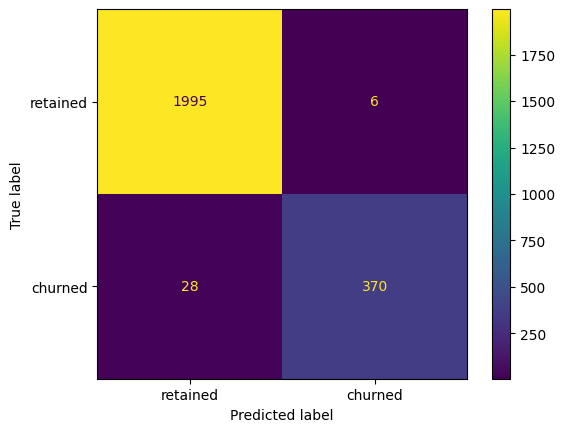

In [78]:
cm = confusion_matrix(y_test, rf_pred_test, labels = rf_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = ['retained','churned'])
disp.plot()

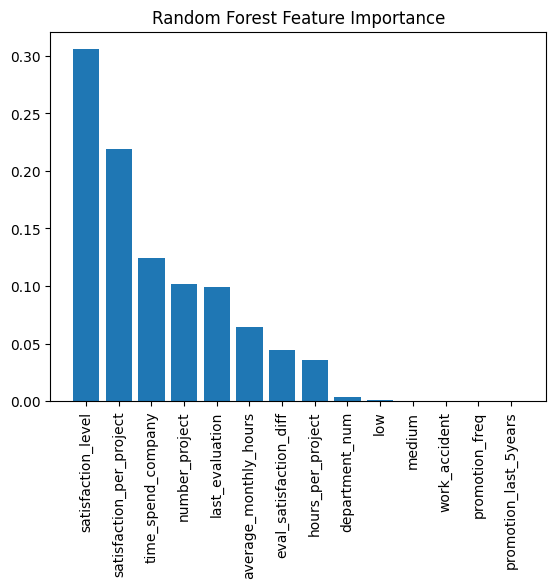

In [60]:

importances = rf_model.feature_importances_
feature_names = X_train.columns


importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

plt.figure()
plt.bar(importance_df["feature"], importance_df["importance"])
plt.xticks(rotation=90)
plt.title("Random Forest Feature Importance")
plt.show()

<Figure size 1800x600 with 0 Axes>

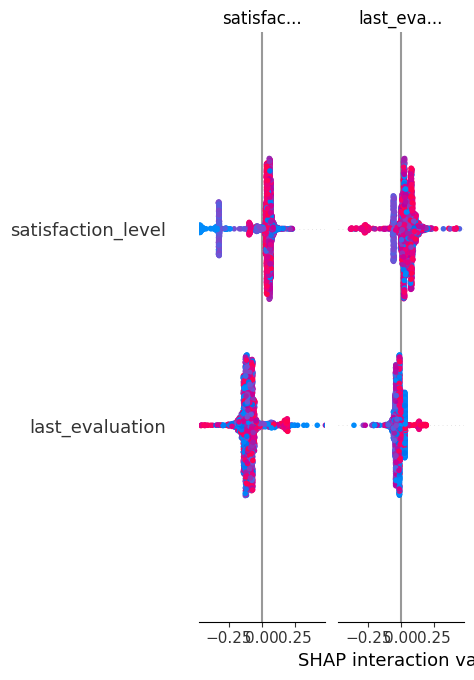

In [69]:

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)
plt.figure(figsize=(18,6))

shap.summary_plot(shap_values, X_test,show=False)
plt.show()


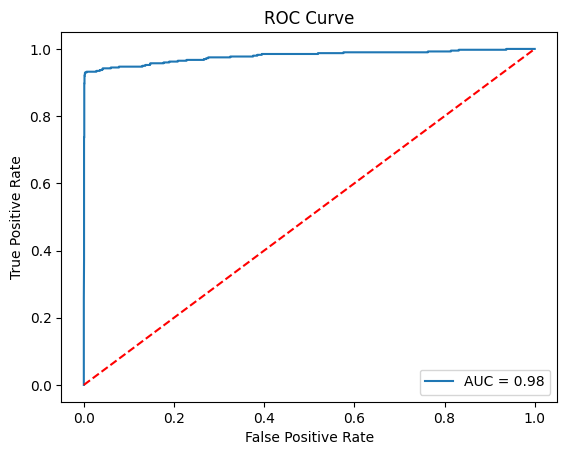

In [71]:
from sklearn.metrics import roc_curve, auc

y_probs = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

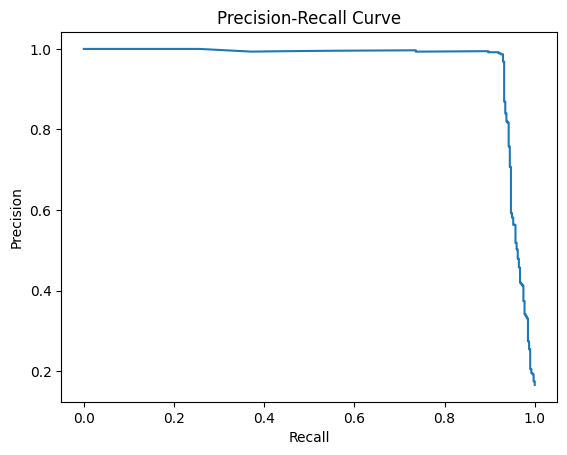

In [72]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

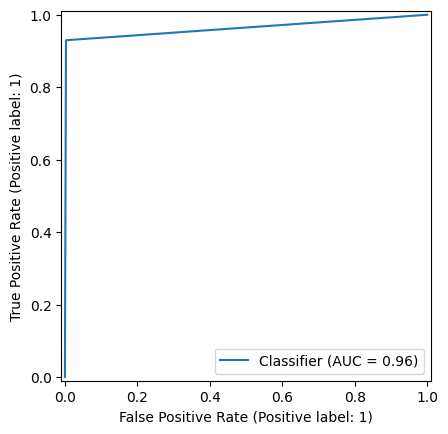

In [74]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, rf_pred_test)
plt.show()

✏
## Recall evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.






💭
### Reflect on these questions as you complete the executing stage.

- What key insights emerged from your model(s)?
- What business recommendations do you propose based on the models built?
- What potential recommendations would you make to your manager/company?
- Do you think your model could be improved? Why or why not? How?
- Given what you know about the data and the models you were using, what other questions could you address for the team?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




### Summary of model results

The rf model has produced highly accurate results. We can be assured of correct categorization of employee retention when using this model. 

Through further analysis, I have determined that satisfaction remains the upmost important factor when it comes to employee retention. Company tenure and workload follow behind as additional important factors.

For an ideal model, there exists a decision threshold (whether a point is determined to churn or retain) where the false positive rate is low and the true positive rate is high. This means that there is a low chance for an empoloyee to be predicted to churn when they are not. At the same time the employees that are predicted to stay, stay. 

Our best estimator is a near perfect model, with the false positive rate near 0% while the true positive rate is near 100%. This is displayed by the ROC curve, where a perfect model would be a point in the upper left corner. 



### Conclusion, Recommendations, Next Steps

- Above everything, satisfaction levels are most imperative to employee retention. I reccomend that we prioritize employee satisfaction as well as better distributing projects across employees. Being overworked is a driving factor in employee retention as well.
- The model already has a 98% precision, meaning it almost never falsely predicts an employee to leave when they were not going to. However, false negatives are slightly more likely to happen. The model can be improved perhaps by adding nonlinear features. This can include an overworked tag, seniority tag, or a feature that is determined by sasisfaction_level and project thresholds rather than a ratio.
- We could do further research into being able to predict satisfaction since that is the leading factor of employee retention. If we are able to see the leading features then we can make the proper accomdations.

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.